<a href="https://colab.research.google.com/github/mythili-97/Python-DA-Assignment-2/blob/main/Python_DA_assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Objective:**The main objective of this assignment is to clean and visualize taxi data using Pandas,Matplotlib and Seaborn.

In [ ]:
import seaborn as sns
# Load the 'taxis' dataset
df = sns.load_dataset("taxis")
df


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(

In [ ]:
df.describe()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total
count,6433,6433,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,2019-03-16 08:31:28.514223616,2019-03-16 08:45:49.491217408,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
min,2019-02-28 23:29:03,2019-02-28 23:32:35,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,2019-03-08 15:50:34,2019-03-08 16:12:51,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,2019-03-15 21:46:58,2019-03-15 22:06:44,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2019-03-23 17:41:38,2019-03-23 17:51:56,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,2019-03-31 23:43:45,2019-04-01 00:13:58,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000
std,NaN,NaN,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570


In [ ]:
#Null values are replaced with mode of the specific columns.
categorical_columns=['payment',	'pickup_zone',	'dropoff_zone','pickup_borough',	'dropoff_borough']
for col in categorical_columns:
 df[col]=df[col].fillna(df[col].mode()[0])


In [ ]:
#There ar no null values in the dataframe
df.duplicated().sum()

np.int64(0)

In [ ]:
#Datatype for pickup time:
df['pickup'].dtype

dtype('<M8[ns]')

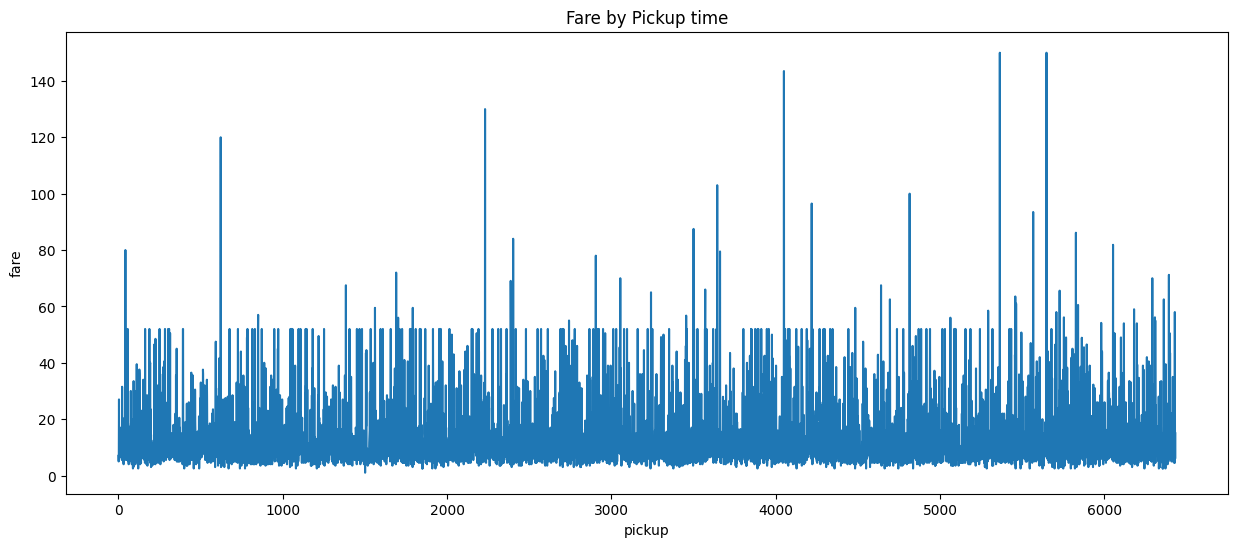

In [ ]:
#Line Chart:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,6))
plt.plot(df.index,df['fare'])
plt.title("Fare by Pickup time")
plt.xlabel("pickup")
plt.ylabel("fare")
plt.show()

Interpretation:Using Line chart,fare amount varies over time.Fare fluctuates over time it has several increases and decreases over time.

In [ ]:
borough_fare=df.groupby('pickup_borough')['fare'].sum()
print(borough_fare)


pickup_borough
Bronx         2078.91
Brooklyn      6327.48
Manhattan    59426.42
Queens       16382.06
Name: fare, dtype: float64


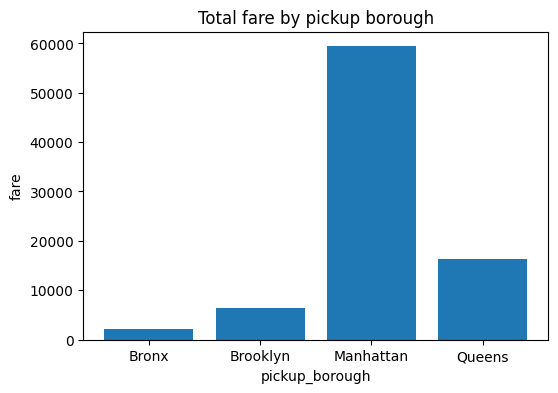

In [ ]:
#Bar Chart:
plt.figure(figsize=(6,4))
bars=plt.bar(borough_fare.index,borough_fare.values)
plt.title('Total fare by pickup borough')
plt.xlabel('pickup_borough')
plt.ylabel('fare')
plt.show()


Interpretation:The bar chart compares fare with pickup_borough.From this Manhattan borough has highest fare values and Bronx borough has lowest fare values.

In [ ]:
#Pie chart:
payment_counts=df['payment'].value_counts()
print(payment_counts)

payment
credit card    4621
cash           1812
Name: count, dtype: int64


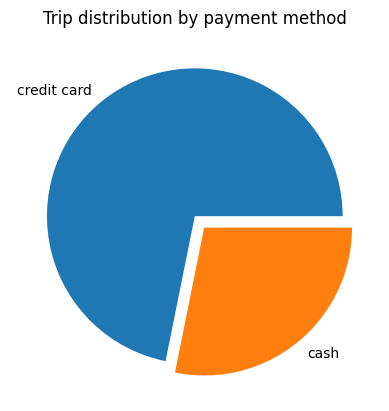

In [ ]:
plt.pie(payment_counts.values,labels=payment_counts.index,explode=[0,0.1])
plt.title('Trip distribution by payment method')
plt.show()

Interpretation:Pie chart shows distribution of trips by payment method.Credit card accounts for largest share of trips while Cash represents smallest share.

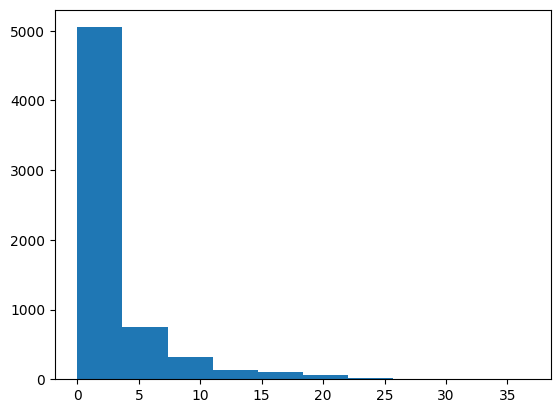

In [ ]:
#Histogram:
plt.hist(df['distance'],bins=10)
plt.show()

Interpretation:The histogram shows most taxi trips are for shorter distances,while number of trips gradually decreases as distance increases.

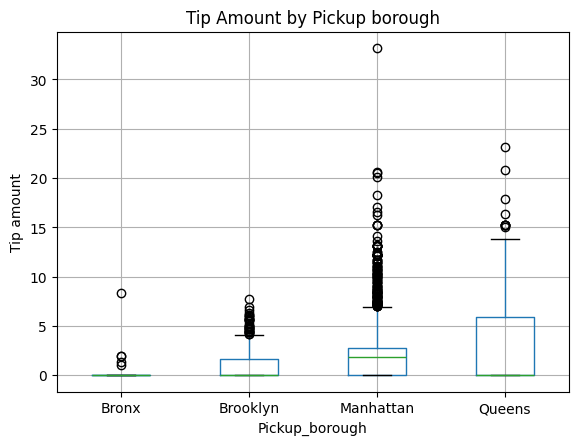

In [ ]:
df.boxplot(column='tip',by='pickup_borough')
plt.xlabel('Pickup_borough')
plt.ylabel('Tip amount')
plt.title("Tip Amount by Pickup borough")
plt.suptitle("")
plt.show()

Interpretation:By box plot,Tip amount vary across pickup boroughs with most values within normal range and one outliers.

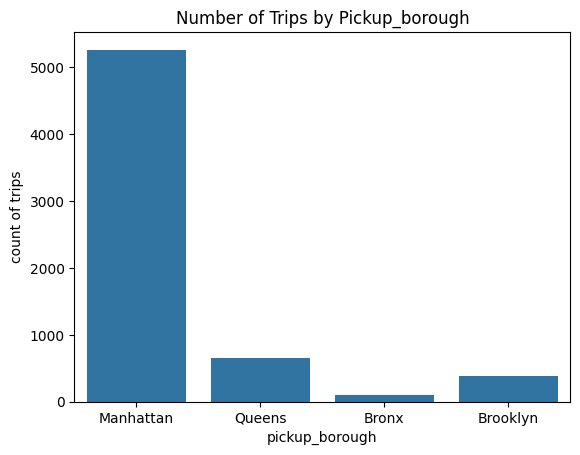

In [ ]:
sns.countplot(data=df, x='pickup_borough')
plt.xlabel('pickup_borough')
plt.ylabel('count of trips')
plt.title('Number of Trips by Pickup_borough')
plt.show()


Interpretation:From count plot,number of trips from Manhattan borough is high and Bronx borough is low.

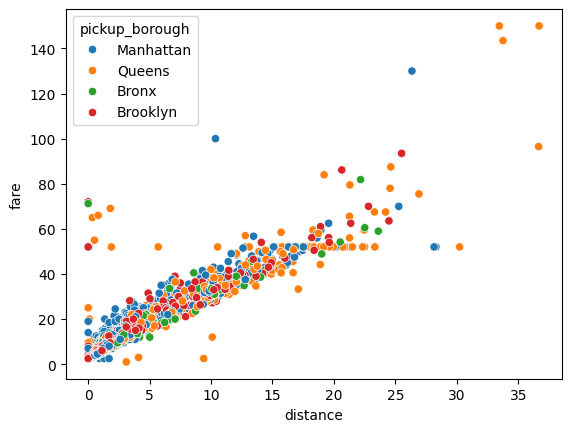

In [ ]:
#Scatterplot"
sns.scatterplot(data=df,x='distance',y='fare',hue='pickup_borough')
plt.show()

Interpretation:The scatter plot shows relationship between trip distance and fare.It indicates that fare increases as distance increases and different colours show how the relationship varies across pickup boroughs.

In [ ]:
#Heatmap:
corr=df[['distance','fare','tip','tolls','total']].corr()
corr

,distance,fare,tip,tolls,total
distance,1.000000,0.920108,0.452589,0.635267,0.904676
fare,0.920108,1.000000,0.488612,0.609307,0.974358
tip,0.452589,0.488612,1.000000,0.413619,0.646186
tolls,0.635267,0.609307,0.413619,1.000000,0.683142
total,0.904676,0.974358,0.646186,0.683142,1.000000


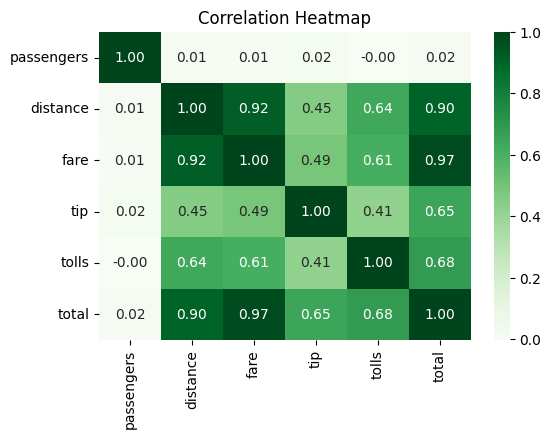

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Greens',fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Interpretation:From heatmap,correlation between distance,fare,tip,tolls and total variables move together in same directions and positive values show positive relationship.

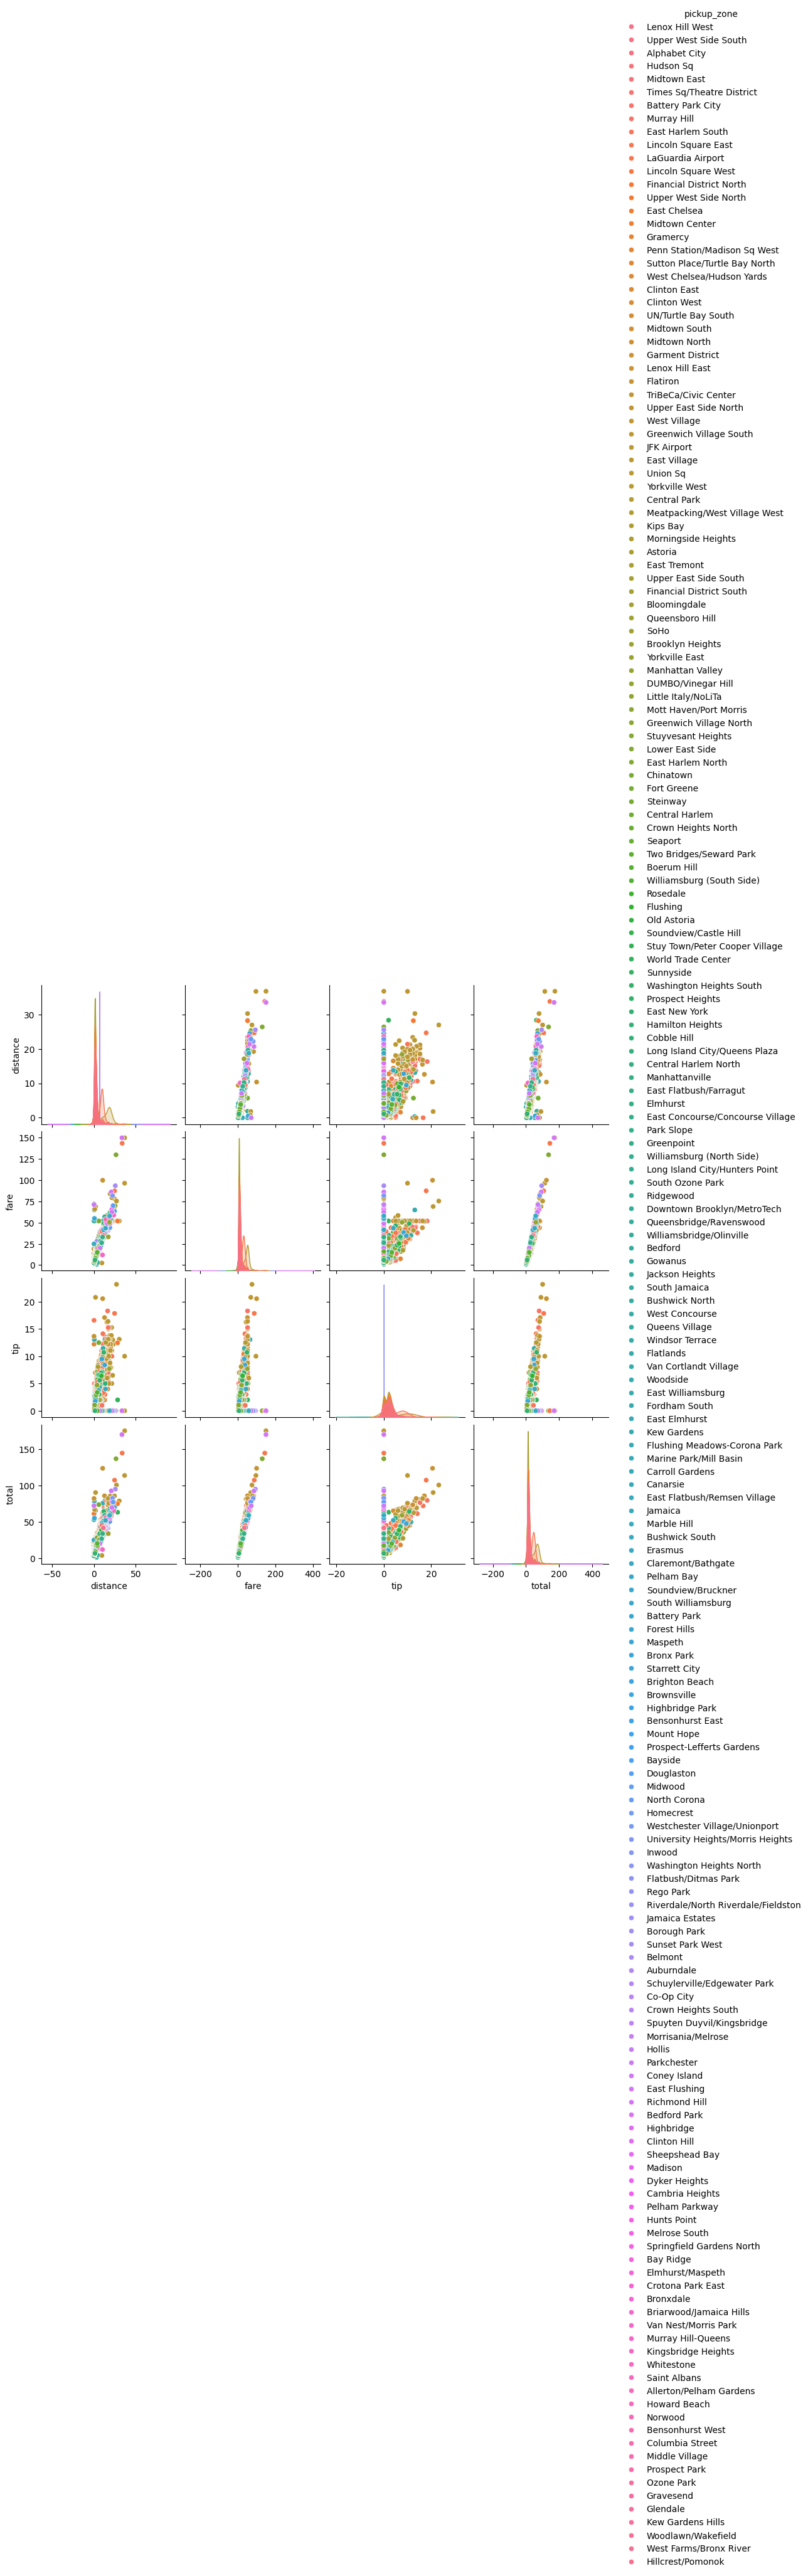

In [ ]:
#Pairplot:
sns.pairplot(df[['distance','fare','tip','total','pickup_zone']],hue='pickup_zone')
plt.show()

Interpretation:Pair plot shows relationships,distributions and oultliers between distance,fare,tip,total,pickup zone and distance,fare have positive relationship.

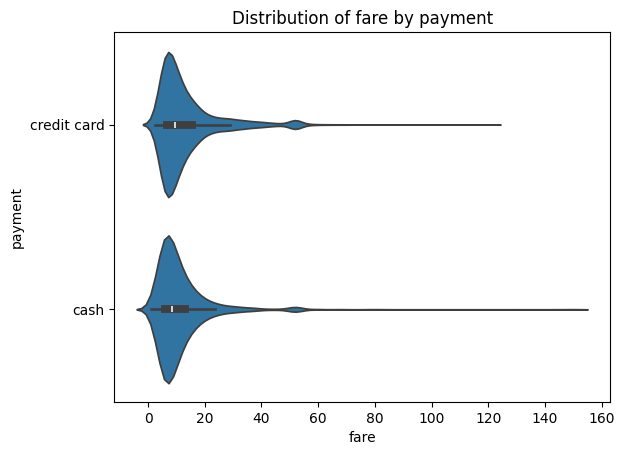

In [ ]:
#Violin Plot:
sns.violinplot(x='fare',y='payment',data=df)
plt.title('Distribution of fare by payment')
plt.xlabel('fare')
plt.ylabel('payment')
plt.show()

Interpretation:The Violin plot compares fare distributions across payment methods.Most fares are concentrated at lower values with some variations in spread of fares between payment methods.